In [2]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib

# -----------------------
# LOAD DATA
# -----------------------
X_train = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\X_train.txt", sep='\s+', header=None)
X_test  = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\X_test.txt", sep='\s+', header=None)

y_train = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\y_train.txt", header=None)
y_test  = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\y_test.txt", header=None)

# FIX labels
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Shapes:", X_train.shape, X_test.shape)

# -----------------------
# SCALE DATA (VERY IMPORTANT)
# -----------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------
# TRAIN MODEL
# -----------------------
model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train, y_train)

# -----------------------
# PREDICTION
# -----------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -----------------------
# SAVE MODEL + SCALER
# -----------------------
joblib.dump(model, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model saved successfully!")

Shapes: (7352, 561) (2947, 561)
Accuracy: 0.9548693586698337
              precision    recall  f1-score   support

           1       0.95      0.97      0.96       496
           2       0.93      0.96      0.95       471
           3       0.97      0.92      0.94       420
           4       0.96      0.90      0.93       491
           5       0.91      0.97      0.94       532
           6       1.00      1.00      1.00       537

    accuracy                           0.95      2947
   macro avg       0.96      0.95      0.95      2947
weighted avg       0.96      0.95      0.95      2947

✅ Model saved successfully!


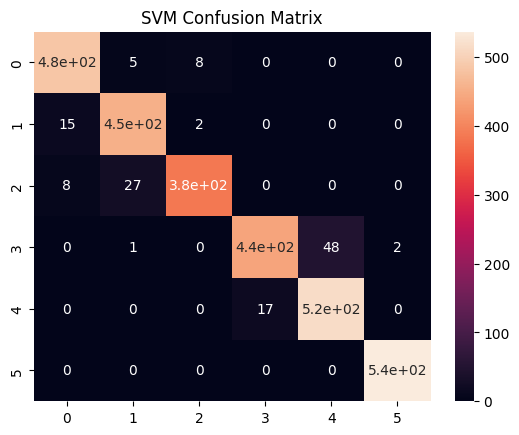

In [5]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title("SVM Confusion Matrix")
plt.savefig("confusion_matrix_svm.png")